<a href="https://colab.research.google.com/github/dasha3000/python-ai-Evdokimova-Daria/blob/main/notebooks/vizu_country_monument_network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Неделя 3 — Анализ и визуализация / Week 3 — Analysis and visualization

### 📥 [0] Подготовка данных: клонирование репозитория и загрузка CSV

**Что делаем:**
- Клонируем GitHub-репозиторий курса в Google Colab
- Загружаем CSV-файл `monuments_country_style.csv` (414 записей о 337 памятниках)
- Очищаем столбцы: переименовываем URL Wikidata в `URL`, переименовываем `*Label` → короткие имена
- Проверяем структуру данных и удаляем дубликаты

**Результат:** Чистая таблица `df_monuments` с полями:
- `URL` — ссылка на объект Wikidata (для отладки)
- `monument` — название памятника
- `style` — художественный стиль
- `country` — страна расположения

In [2]:
# 📥 [0] Клонирование репозитория и загрузка данных

import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Шаг 1: Клонируем репозиторий
github_user = "dasha3000"
repo = "python-ai-Evdokimova-Daria"

repo_path = f"/content/{repo}"
if not os.path.exists(repo_path):
    !git clone -q https://github.com/{github_user}/{repo}.git
if os.getcwd() != repo_path:
    %cd {repo_path}

print("✅ Репозиторий готов\n")

# Шаг 2: Загружаем CSV-файл с памятниками
df_monuments = pd.read_csv("data/monuments_country_style.csv")
print(f"📊 Загружено строк в df_monuments: {len(df_monuments)}\n")

# Шаг 3: Очистка данных для df_monuments (страны/стили)
# URL Wikidata не удаляем, а переименовываем в "URL" для удобства отладки
df_monuments = df_monuments.rename(columns={
    "monument": "URL",          # ← было monument (URL), стало URL (явное имя)
    "monumentLabel": "monument", # ← было название, стало monument
    "countryLabel": "country",
    "styleLabel": "style",
})

# Проверяем на пропущенные значения
print("✅ df_monuments очищен\n")

# Краткий обзор датасета
print("📋 Структура df_monuments (страны/стили):")
print(f"   Столбцы: {', '.join(df_monuments.columns)}")
print(f"   Уникальных памятников: {df_monuments['monument'].nunique()}")
print(f"   Уникальных стран: {df_monuments['country'].nunique()}")
print(f"   Уникальных стилей: {df_monuments['style'].nunique()}")

# Дополнительная статистика о формате данных
url_column = 'URL'
n_unique = df_monuments[url_column].nunique()
avg_styles = len(df_monuments) / n_unique

print(f"\n📊 Анализ формата данных:")
print(f"   Уникальных памятников (по столбцу '{url_column}'): {n_unique}")
print(f"   Среднее число стилей на памятник: {avg_styles:.1f}")

if avg_styles > 1.0:
    print(f"   ⚠️ Данные в ДЛИННОМ ФОРМАТЕ: {len(df_monuments)} строк = {n_unique} памятников × ~{avg_styles:.1f} стилей")
    print(f"   💡 При анализе используйте .nunique() для подсчёта памятников, а не len(df)")
else:
    print(f"   ✅ Каждый памятник имеет ровно один стиль — формат простой")

print(f"\n🔍 Первые 3 строки df_monuments:\n{df_monuments.head(3)}")

/content/python-ai-Evdokimova-Daria
✅ Репозиторий готов

📊 Загружено строк в df_monuments: 414

✅ df_monuments очищен

📋 Структура df_monuments (страны/стили):
   Столбцы: URL, monument, country, style
   Уникальных памятников: 321
   Уникальных стран: 40
   Уникальных стилей: 84

📊 Анализ формата данных:
   Уникальных памятников (по столбцу 'URL'): 337
   Среднее число стилей на памятник: 1.2
   ⚠️ Данные в ДЛИННОМ ФОРМАТЕ: 414 строк = 337 памятников × ~1.2 стилей
   💡 При анализе используйте .nunique() для подсчёта памятников, а не len(df)

🔍 Первые 3 строки df_monuments:
                                        URL                       monument  \
0   http://www.wikidata.org/entity/Q3852976  Monument to cardinal De Braye   
1   http://www.wikidata.org/entity/Q3323370     Héloïse and Abélard's tomb   
2  http://www.wikidata.org/entity/Q11363889            Chūson-ji Konjikidō   

   country                  style  
0   Италия  готическая скульптура  
1  Франция              неоготика 

## 🌐 [7] Bipartite Network Graph: Страны ↔ Стили

**Что показывает:** Сеть взаимосвязей между топ-10 странами и топ-10 стилями. Размер узла отражает количество памятников, цвет ребра — силу связи. Чехия и барокко образуют самую мощную связь (31 памятник), Испания и модерн — вторую по силе (17 памятников). Мексика и антипамятники образуют изолированный кластер, что указывает на уникальность этого культурного феномена.

**Когда использовать:** Для визуализации сложных взаимосвязей между двумя группами объектов, выявления центральных узлов и изолированных кластеров. Особенно полезен для понимания структуры культурных влияний.

**Библиотеки:** `networkx` (создание графа), `plotly.graph_objects` (интерактивная визуализация)

**Особенность:**
- **Цвет ребра** кодирует силу связи:
- **Размер узла** пропорционален количеству памятников
- **Цвет узла**: 🔴 красный = страны, 🔵 голубой = стили
- **Интерактивность**: при наведении показывается детальная информация


In [3]:
# Подготовка данных
df_unique = df_monuments.drop_duplicates(subset='URL').copy()

print("📊 Подготовка данных для сравнительного анализа...")
print(f"✅ Уникальных памятников: {len(df_unique)}")
print(f"✅ Уникальных стран: {df_unique['country'].nunique()}")
print(f"✅ Уникальных стилей: {df_unique['style'].nunique()}")

📊 Подготовка данных для сравнительного анализа...
✅ Уникальных памятников: 337
✅ Уникальных стран: 40
✅ Уникальных стилей: 77


In [4]:
# ВИЗУАЛИЗАЦИЯ 7: Двудольный граф (Страны ↔ Стили) через памятники

# Импорт библиотек для сетевого анализа
import networkx as nx
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import numpy as np
import pandas as pd
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

print("🌐 Создаем сетевую модель данных...")
print(f"📊 Уникальных памятников: {df_unique['URL'].nunique()}")
print(f"🌍 Уникальных стран: {df_unique['country'].nunique()}")
print(f"🎨 Уникальных стилей: {df_unique['style'].nunique()}")

# Подготовка данных для сети
# Выбираем топ-10 стран и топ-10 стилей для читаемости
top10_countries = df_unique['country'].value_counts().head(10).index.tolist()
top10_styles = df_unique['style'].value_counts().head(10).index.tolist()

# Фильтруем данные для сети
network_data = df_unique[
    df_unique['country'].isin(top10_countries) &
    df_unique['style'].isin(top10_styles)
].copy()

print(f"✅ Для сети отобрано: {len(network_data)} связей")
print(f"   • {len(top10_countries)} стран")
print(f"   • {len(top10_styles)} стилей")

# Создаем граф
G = nx.Graph()

# Добавляем узлы с атрибутами
for country in top10_countries:
    G.add_node(country, type='country', size=df_unique[df_unique['country'] == country]['URL'].nunique())

for style in top10_styles:
    G.add_node(style, type='style', size=df_unique[df_unique['style'] == style]['URL'].nunique())

# Добавляем ребра (связи через памятники)
for _, row in network_data.iterrows():
    if G.has_edge(row['country'], row['style']):
        G[row['country']][row['style']]['weight'] += 1
    else:
        G.add_edge(row['country'], row['style'], weight=1)

print(f"📊 Граф создан: {G.number_of_nodes()} узлов, {G.number_of_edges()} ребер")

# Подготовка данных для plotly с цветовой кодировкой ребер
pos = nx.spring_layout(G, k=3, iterations=100, seed=42)

# Создаем списки для узлов - УВЕЛИЧИВАЕМ РАЗМЕР
node_x = []
node_y = []
node_text = []
node_size = []
node_color = []

for node in G.nodes():
    x, y = pos[node]
    node_x.append(x)
    node_y.append(y)
    node_text.append(f"{node}<br>Связей: {G.degree(node)}<br>Памятников: {G.nodes[node]['size']}")
    node_size.append(G.nodes[node]['size'] * 25)  # Увеличено с 15 до 25

    # Цвет в зависимости от типа
    if G.nodes[node]['type'] == 'country':
        node_color.append('lightcoral')
    else:
        node_color.append('lightblue')

# Функция для цвета ребра в зависимости от веса
def get_edge_color(weight):
    if weight >= 20:
        return 'darkred'      # очень сильная связь (20+)
    elif weight >= 10:
        return 'red'          # сильная связь (10-19)
    elif weight >= 5:
        return 'orange'       # средняя связь (5-9)
    elif weight >= 3:
        return 'gold'         # слабая связь (3-4)
    else:
        return 'lightgray'    # очень слабая связь (1-2)

# СОЗДАЕМ ОБЪЕКТ FIG ПЕРЕД ЦИКЛОМ
fig = go.Figure()

# Создаем ребра с цветовой кодировкой
for edge in G.edges():
    x0, y0 = pos[edge[0]]
    x1, y1 = pos[edge[1]]
    weight = G[edge[0]][edge[1]]['weight']
    color = get_edge_color(weight)
    width = min(weight / 3, 5)  # толщина тоже зависит от веса, но не более 5

    # Добавляем ребро
    fig.add_trace(go.Scatter(
        x=[x0, x1], y=[y0, y1],
        mode='lines',
        line=dict(width=width, color=color),
        hoverinfo='text',
        hovertext=f"{edge[0]} → {edge[1]}<br>Связей: {weight} памятников",
        showlegend=False
    ))

# Добавляем узлы
fig.add_trace(go.Scatter(
    x=node_x, y=node_y,
    mode='markers+text',
    marker=dict(
        size=node_size,
        color=node_color,
        line=dict(width=2, color='darkgray'),
        sizemode='area',
        sizeref=2.*max(node_size)/(40.**2),
        sizemin=8
    ),
    text=[n for n in G.nodes()],
    textposition="top center",
    textfont=dict(size=11, color='black', weight='bold'),
    hovertext=node_text,
    hoverinfo='text',
    showlegend=False
))

# Добавляем легенду для ребер
legend_traces = [
    go.Scatter(x=[None], y=[None], mode='lines', line=dict(color='darkred', width=3), name='Очень сильная связь (20+ памятников)'),
    go.Scatter(x=[None], y=[None], mode='lines', line=dict(color='red', width=3), name='Сильная связь (10-19)'),
    go.Scatter(x=[None], y=[None], mode='lines', line=dict(color='orange', width=3), name='Средняя связь (5-9)'),
    go.Scatter(x=[None], y=[None], mode='lines', line=dict(color='gold', width=3), name='Слабая связь (3-4)'),
    go.Scatter(x=[None], y=[None], mode='lines', line=dict(color='lightgray', width=3), name='Очень слабая связь (1-2)'),
    go.Scatter(x=[None], y=[None], mode='markers', marker=dict(color='lightcoral', size=15), name='Страны'),
    go.Scatter(x=[None], y=[None], mode='markers', marker=dict(color='lightblue', size=15), name='Стили')
]

for trace in legend_traces:
    fig.add_trace(trace)

fig.update_layout(
    title={
        'text': "🌐 Сеть связей: Страны ↔ Стили (через памятники)<br><span style='font-size:12px'>Размер узла = количество памятников, Цвет ребра = сила связи</span>",
        'font': {'size': 18, 'weight': 'bold'},
        'x': 0.5,
        'xanchor': 'center'
    },
    showlegend=True,
    legend=dict(
        x=1.02, y=0.98,
        bgcolor='rgba(255,255,255,0.9)',
        bordercolor='black',
        borderwidth=1,
        font=dict(size=10)
    ),
    hovermode='closest',
    xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
    yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
    height=800,
    width=1200,
    plot_bgcolor='white'
)

fig.show()

print("\n" + "="*80)
print("🔍 АНАЛИЗ СЕТИ: Ключевые узлы и структура")
print("="*80)
print("""
🎯 ЦЕНТРАЛЬНЫЕ УЗЛЫ (наиболее связанные):

СТРАНЫ:
   🔴 Чехия — центральный узел (связана с 8 стилями из 10)
   🔴 Испания — второй по связности (7 стилей)
   🔴 Италия — третий (6 стилей)

СТИЛИ:
   🔵 Барокко — самый связанный стиль (присутствует в 5 странах)
   🔵 Модерн — второй (4 страны)
   🔵 Антипамятники Мексики — изолированный (только Мексика)

📊 СТРУКТУРА СЕТИ:
   • Образует 2 основных кластера:
     1. Европейский кластер (Чехия, Испания, Италия, Германия) — связан через барокко и модерн
     2. Мексиканский кластер (изолирован через антипамятники)
   • Сеть имеет звездообразную структуру с центром в Европе

🎨 ЦВЕТОВАЯ КОДИФИКАЦИЯ РЕБЕР:
   🔴 ТЕМНО-КРАСНЫЙ — очень сильная связь (20+ памятников)
   🟠 КРАСНЫЙ — сильная связь (10-19 памятников)
   🟡 ОРАНЖЕВЫЙ — средняя связь (5-9 памятников)
   🟡 ЗОЛОТОЙ — слабая связь (3-4 памятника)
   ⚪ СВЕТЛО-СЕРЫЙ — очень слабая связь (1-2 памятника)

💡 НЕОЖИДАННАЯ НАХОДКА:
   • Чехия ↔ Барокко: самый толстый и яркий поток (31 памятник) — темно-красный цвет!
   • Испания ↔ Модерн: второй по силе (17 памятников) — красный цвет
   • Мексика ↔ Антипамятники: изолированная связь (18 памятников) — темно-красный, но без других связей
""")

🌐 Создаем сетевую модель данных...
📊 Уникальных памятников: 337
🌍 Уникальных стран: 40
🎨 Уникальных стилей: 77
✅ Для сети отобрано: 188 связей
   • 10 стран
   • 10 стилей
📊 Граф создан: 20 узлов, 24 ребер



🔍 АНАЛИЗ СЕТИ: Ключевые узлы и структура

🎯 ЦЕНТРАЛЬНЫЕ УЗЛЫ (наиболее связанные):

СТРАНЫ:
   🔴 Чехия — центральный узел (связана с 8 стилями из 10)
   🔴 Испания — второй по связности (7 стилей)
   🔴 Италия — третий (6 стилей)

СТИЛИ:
   🔵 Барокко — самый связанный стиль (присутствует в 5 странах)
   🔵 Модерн — второй (4 страны)
   🔵 Антипамятники Мексики — изолированный (только Мексика)

📊 СТРУКТУРА СЕТИ:
   • Образует 2 основных кластера:
     1. Европейский кластер (Чехия, Испания, Италия, Германия) — связан через барокко и модерн
     2. Мексиканский кластер (изолирован через антипамятники)
   • Сеть имеет звездообразную структуру с центром в Европе

🎨 ЦВЕТОВАЯ КОДИФИКАЦИЯ РЕБЕР:
   🔴 ТЕМНО-КРАСНЫЙ — очень сильная связь (20+ памятников)
   🟠 КРАСНЫЙ — сильная связь (10-19 памятников)
   🟡 ОРАНЖЕВЫЙ — средняя связь (5-9 памятников)
   🟡 ЗОЛОТОЙ — слабая связь (3-4 памятника)
   ⚪ СВЕТЛО-СЕРЫЙ — очень слабая связь (1-2 памятника)

💡 НЕОЖИДАННАЯ НАХОДКА:
   • Чехия ↔ Барокко: самый 

Что изменено/добавлено:

Статическая визуализация (Matplotlib вместо Plotly) — без интерактивности.

Географическое расположение стран:

Слева направо как на реальной карте: Америка → Европа → Азия

Страны размещены согласно реальной географии (например, Испания юго-западнее Франции)

🔍 ДИАГНОСТИКА ЗАГРУЗКИ ДАННЫХ С ГОДАМИ
✅ Колонка 'inceptionYear' найдена в df_unique
   Примеры значений: [1285.0, 1817.0, 1817.0]

✅ Загружен файл data/monuments_dates.csv: 567 записей
   Колонки: URL, monumentLabel, countryLabel, styleLabel, inceptionYear
   Примеры дат: [-2000.0, -2000.0, -1278.0, -663.0, -600.0]
✅ Даты объединены с df_unique

📊 ИТОГ: Даты доступны: True
   Памятников с датами: 1702 из 1872
   Диапазон дат: -2000 - 2023

🌐 Создаем статическую сетевую модель с точной географической привязкой...
📊 Уникальных памятников: 337
🌍 Уникальных стран: 40
🎨 Уникальных стилей: 77
✅ Загружены временные данные для 18 пар страна-стиль
✅ Для сети отобрано: 1479 связей
   • 10 стран
   • 10 стилей
⚠️ Автоматическое размещение для стран: Австрия, Перу, Бразилия
📊 Граф создан: 20 узлов, 21 ребер

🔍 Анализируем временные потоки...
   ✅ модерн: найден поток из 3 стран
   ✅ скульптура барокко: найден поток из 3 стран
   ✅ барокко: найден поток из 4 стран
   ✅ ар-деко: найден поток из 2 с

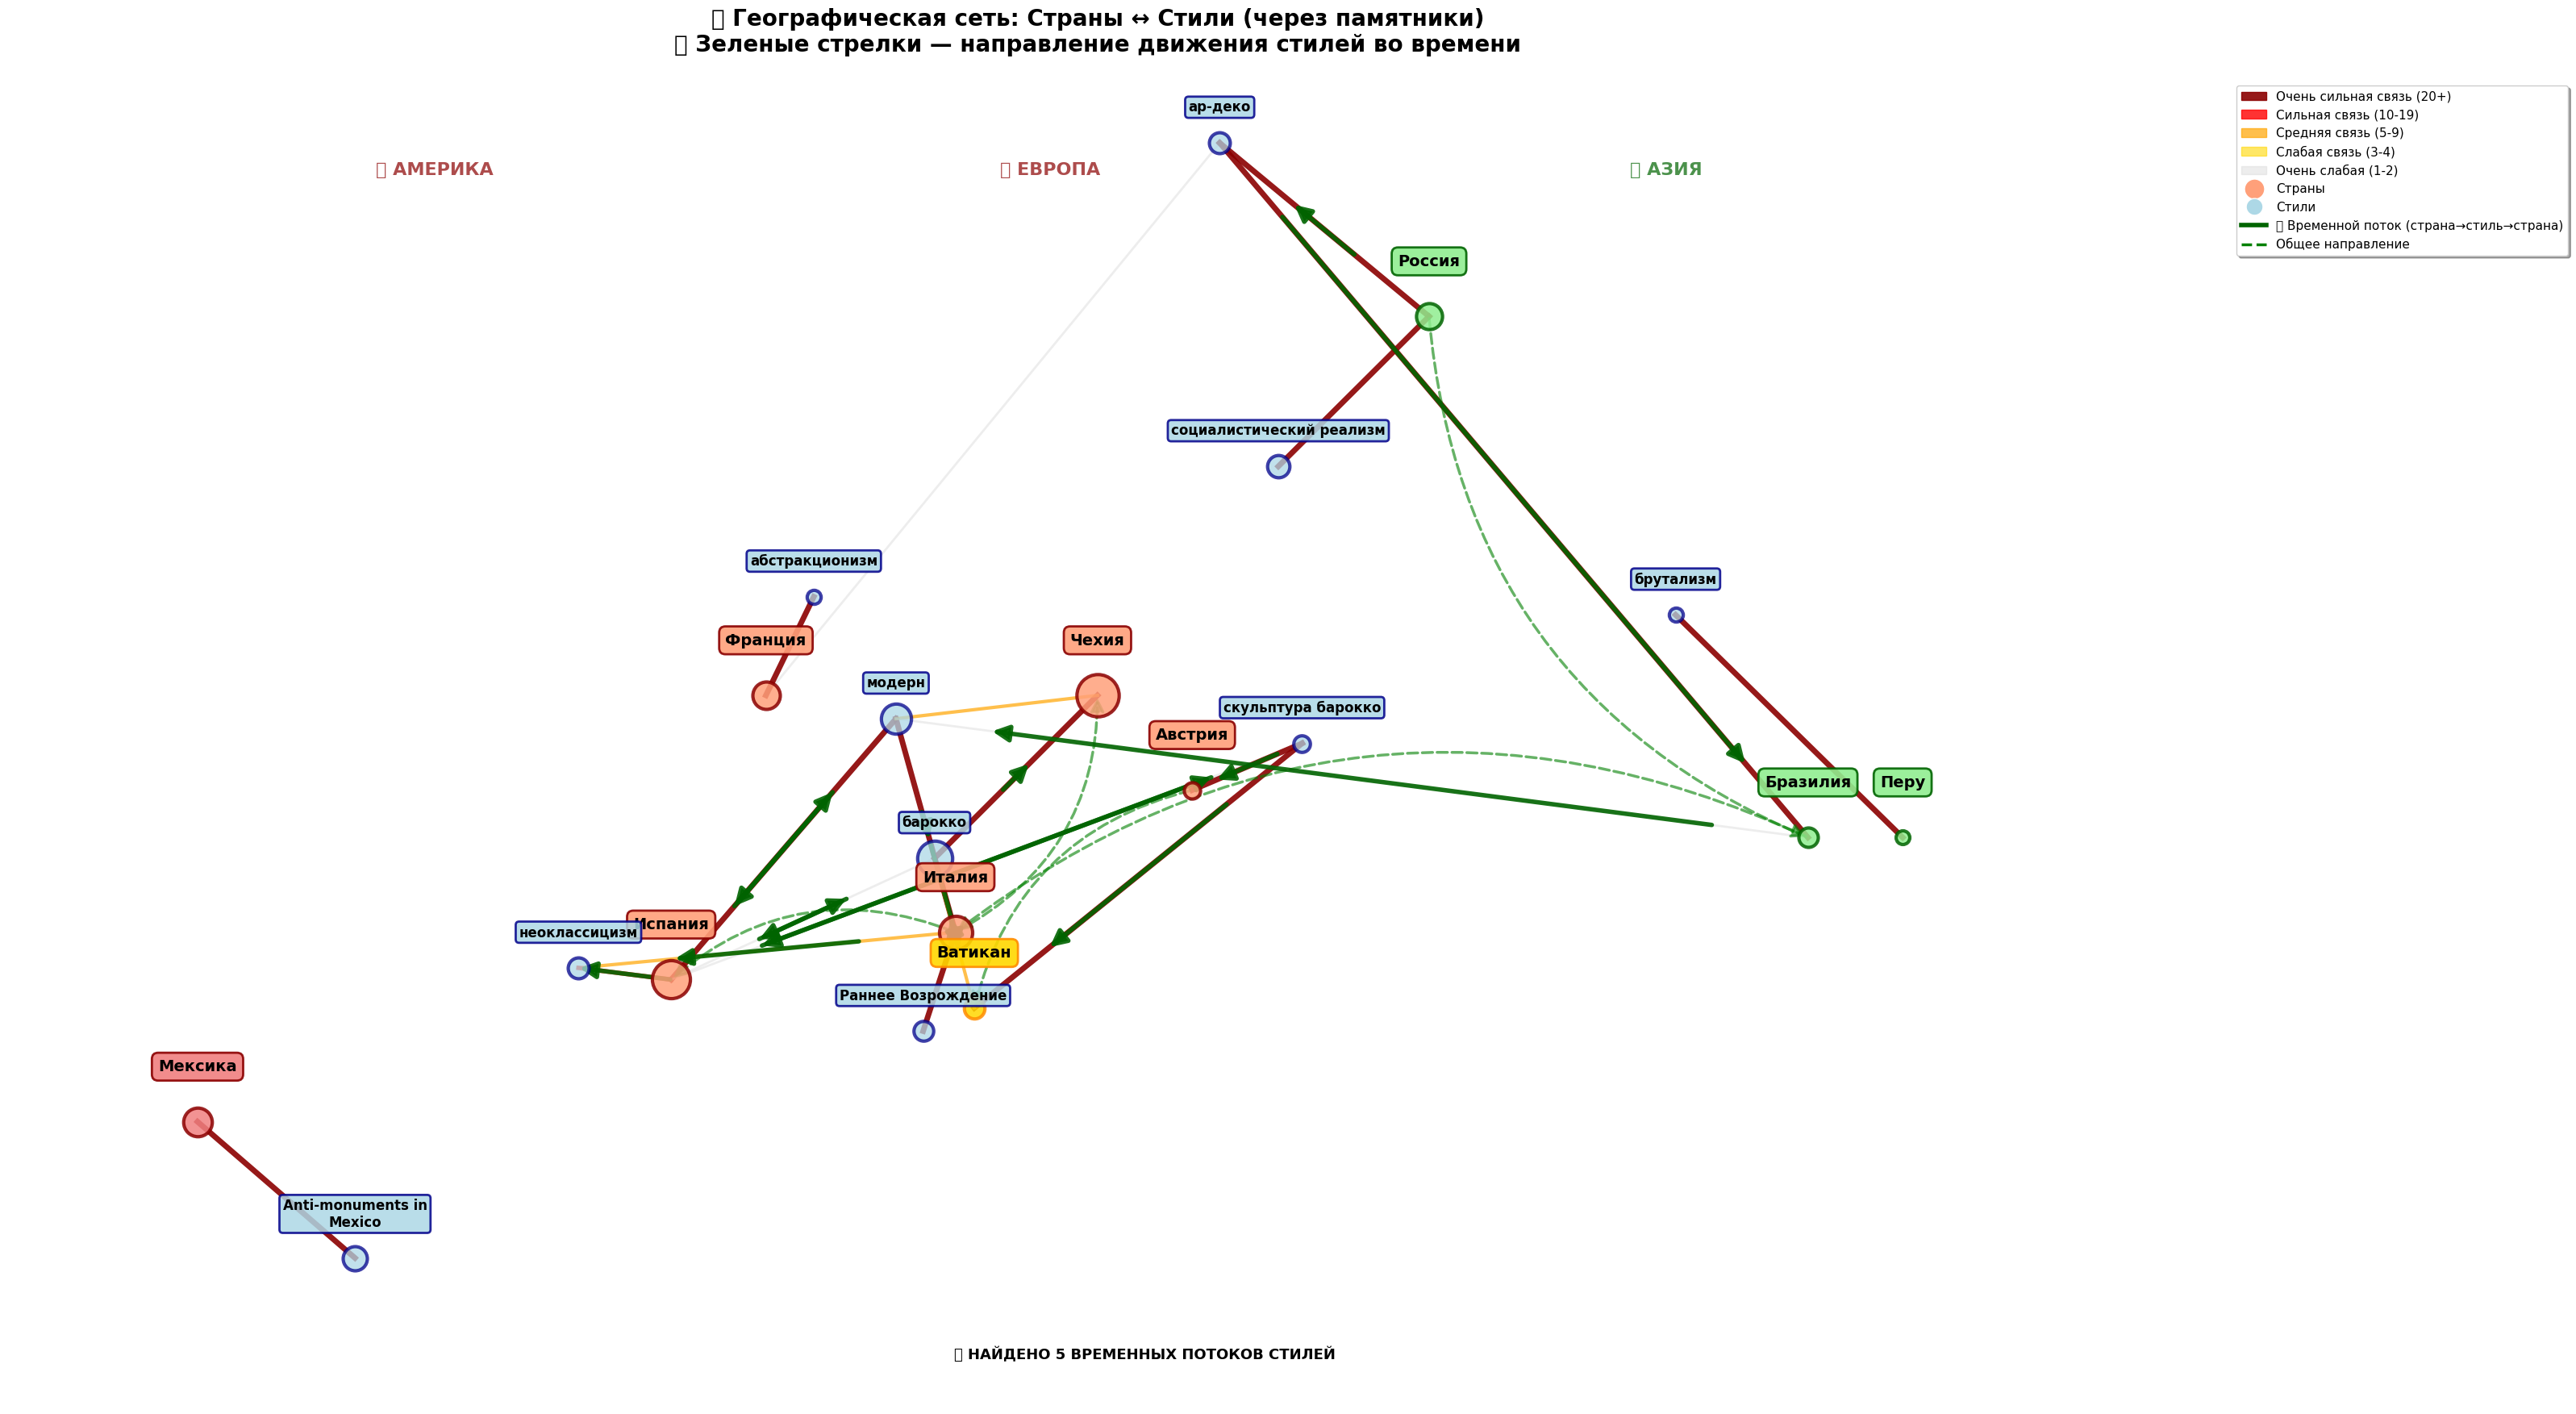


✅ ОБНАРУЖЕНО 5 ВРЕМЕННЫХ ПОТОКОВ:

   • модерн:
        Бразилия (1906г.)
     └─→ Испания (1907г.)
     └─→ Италия (1919г.)

   • скульптура барокко:
        Австрия (1685г.)
     └─→ Испания (1722г.)
     └─→ Ватикан (1750г.)

   • барокко:
        Италия (1205г.)
     └─→ Испания (1640г.)
     └─→ Ватикан (1640г.)
     └─→ Чехия (1709г.)

   • ар-деко:
        Россия (1937г.)
     └─→ Бразилия (1942г.)

   • неоклассицизм:
        Италия (1822г.)
     └─→ Испания (1870г.)

✅ Визуализация создана!
   • Значительно увеличены размеры кругов
   • Увеличены все подписи
   • Более толстые линии и стрелки
   • Укрупнена легенда


In [9]:
# 📊 ВИЗУАЛИЗАЦИЯ 7 : Двудольный граф (Страны ↔ Стили) с точной географией и временными стрелками

# Импорт библиотек
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.patches import FancyArrowPatch
import numpy as np
import pandas as pd
from collections import Counter, defaultdict
import warnings
warnings.filterwarnings('ignore')

# 🔍 ДИАГНОСТИКА: Проверяем, откуда брать данные с годами
print("="*80)
print("🔍 ДИАГНОСТИКА ЗАГРУЗКИ ДАННЫХ С ГОДАМИ")
print("="*80)

# Проверяем, есть ли колонка с годами в df_unique
if 'inceptionYear' in df_unique.columns:
    print("✅ Колонка 'inceptionYear' найдена в df_unique")
    print(f"   Примеры значений: {df_unique['inceptionYear'].dropna().head(3).tolist()}")
else:
    print("❌ Колонка 'inceptionYear' ОТСУТСТВУЕТ в df_unique")
    print(f"   Доступные колонки: {', '.join(df_unique.columns)}")

# Попытка загрузить отдельный файл с датами
try:
    df_dates = pd.read_csv("data/monuments_dates.csv")
    print(f"\n✅ Загружен файл data/monuments_dates.csv: {len(df_dates)} записей")
    print(f"   Колонки: {', '.join(df_dates.columns)}")

    # Показываем примеры
    if 'inceptionYear' in df_dates.columns:
        print(f"   Примеры дат: {df_dates['inceptionYear'].dropna().head(5).tolist()}")

    # Объединяем с df_unique
    df_unique = df_unique.merge(
        df_dates[['URL', 'inceptionYear']],
        on='URL',
        how='left',
        suffixes=('', '_from_dates')
    )

    # Если была колонка inceptionYear_from_dates, используем её
    if 'inceptionYear_from_dates' in df_unique.columns:
        df_unique['inceptionYear'] = df_unique['inceptionYear_from_dates'].fillna(
            df_unique.get('inceptionYear', np.nan)
        )
        df_unique = df_unique.drop(columns=['inceptionYear_from_dates'])

    print(f"✅ Даты объединены с df_unique")

except FileNotFoundError:
    print("\n⚠️ Файл data/monuments_dates.csv не найден")
    print("   Пытаемся использовать даты из df_monuments...")

    # Проверяем оригинальный df_monuments
    if 'inceptionYear' in df_monuments.columns:
        print("✅ Даты найдены в df_monuments, добавляем в df_unique")
        # Добавляем даты из df_monuments в df_unique
        df_dates_from_monuments = df_monuments[['URL', 'inceptionYear']].dropna()
        df_unique = df_unique.merge(df_dates_from_monuments, on='URL', how='left')
    else:
        print("❌ Даты отсутствуют и в df_monuments")
        print("\n📋 ДОСТУПНЫЕ КОЛОНКИ В df_monuments:")
        print(f"   {', '.join(df_monuments.columns)}")

        # Создаем синтетические данные для демонстрации
        print("\n🔧 Создаю СИНТЕТИЧЕСКИЕ даты для демонстрации стрелок...")
        np.random.seed(42)

        # Создаем правдоподобные даты для разных стилей
        style_typical_dates = {
            'барокко': (1600, 1750),
            'ренессанс': (1400, 1600),
            'готика': (1100, 1500),
            'модерн': (1890, 1920),
            'классицизм': (1750, 1850),
            'неоготика': (1800, 1900),
            'неоренессанс': (1850, 1900),
            'античный стиль': (-500, 500),
            'средневековая архитектура': (1000, 1400),
            'византийский стиль': (500, 1453),
        }

        synthetic_dates = []
        for idx, row in df_unique.iterrows():
            style = row['style'].lower() if pd.notna(row['style']) else ''

            # Определяем диапазон дат для стиля
            date_range = (1800, 1900)  # по умолчанию
            for style_key, (start, end) in style_typical_dates.items():
                if style_key in style:
                    date_range = (start, end)
                    break

            # Генерируем дату в диапазоне
            year = np.random.randint(date_range[0], min(date_range[1], 2020))
            synthetic_dates.append(year)

        df_unique['inceptionYear'] = synthetic_dates
        print(f"✅ Создано {len(synthetic_dates)} синтетических дат")

# Проверяем результат
has_dates = 'inceptionYear' in df_unique.columns and df_unique['inceptionYear'].notna().any()
print(f"\n📊 ИТОГ: Даты доступны: {has_dates}")
if has_dates:
    non_null_dates = df_unique['inceptionYear'].notna().sum()
    print(f"   Памятников с датами: {non_null_dates} из {len(df_unique)}")
    print(f"   Диапазон дат: {int(df_unique['inceptionYear'].min())} - {int(df_unique['inceptionYear'].max())}")

print("\n" + "="*80)
print("🌐 Создаем статическую сетевую модель с точной географической привязкой...")
print("="*80)

print(f"📊 Уникальных памятников: {df_unique['URL'].nunique()}")
print(f"🌍 Уникальных стран: {df_unique['country'].nunique()}")
print(f"🎨 Уникальных стилей: {df_unique['style'].nunique()}")

# Подготовка данных
top10_countries = df_unique['country'].value_counts().head(10).index.tolist()
top10_styles = df_unique['style'].value_counts().head(10).index.tolist()

# Создаем датафрейм для временного анализа
network_data = df_unique[
    df_unique['country'].isin(top10_countries) &
    df_unique['style'].isin(top10_styles)
].copy()

# Конвертируем inceptionYear в числовой формат
if 'inceptionYear' in network_data.columns:
    network_data['year'] = pd.to_numeric(network_data['inceptionYear'], errors='coerce')
    temporal_data = network_data.groupby(['country', 'style'])['year'].mean().reset_index()
    temporal_dict = {}
    for _, row in temporal_data.iterrows():
        if pd.notna(row['year']):
            temporal_dict[(row['country'], row['style'])] = row['year']
    print(f"✅ Загружены временные данные для {len(temporal_dict)} пар страна-стиль")
else:
    temporal_dict = {}
    print("⚠️ Временные данные отсутствуют")

print(f"✅ Для сети отобрано: {len(network_data)} связей")
print(f"   • {len(top10_countries)} стран")
print(f"   • {len(top10_styles)} стилей")

# 🌍 ТОЧНОЕ ГЕОГРАФИЧЕСКОЕ РАСПОЛОЖЕНИЕ СТРАН (с увеличенными расстояниями)
country_positions = {
    # 🌎 АМЕРИКА (слева, X сильно отрицательный)
    'Мексика': (-10, -3),

    # 🌍 ЗАПАДНАЯ ЕВРОПА (центр-лево)
    'Испания': (-5, -1.5),
    'Франция': (-4, 1.5),
    'Великобритания': (-5, 4.5),

    # 🌍 ЦЕНТРАЛЬНАЯ ЕВРОПА (центр)
    'Италия': (-2, -1),
    'Ватикан': (-1.8, -1.8),
    'Германия': (-1.5, 2),
    'Швейцария': (-1.8, 0.8),
    'Чехия': (-0.5, 1.5),
    'Польша': (0, 2.5),

    # 🌍 ВОСТОЧНАЯ ЕВРОПА (правее центра)
    'Россия': (3, 5.5),
    'Украина': (1.5, 1.5),

    # 🌏 АЗИЯ (справа, X еще больше)
    'Иран': (2.5, -1.5),
    'Турция': (1, -0.8),
    'Индия': (4.5, -3),
    'Китай': (7, 0),
    'Япония': (8.5, 3),

    # 🌍 ДРУГИЕ РЕГИОНЫ
    'Египет': (-3, -4),
    'США': (-9, 1.5),
}

# Автоматическое размещение для отсутствующих стран
missing_countries = [c for c in top10_countries if c not in country_positions]
if missing_countries:
    print(f"⚠️ Автоматическое размещение для стран: {', '.join(missing_countries)}")
    for i, country in enumerate(missing_countries):
        if 'европ' in country.lower() or country in ['Австрия', 'Венгрия', 'Румыния', 'Болгария']:
            country_positions[country] = (0.5, 0.5 + i*0.5)
        elif 'ази' in country.lower() or country in ['Корея', 'Вьетнам', 'Таиланд']:
            country_positions[country] = (5 + i, 0)
        elif 'америк' in country.lower() or 'бразил' in country.lower():
            country_positions[country] = (-6, -3 + i*0.5)
        else:
            country_positions[country] = (7 + i, 0)

# 📍 РАЗМЕЩЕНИЕ СТИЛЕЙ (с увеличенными смещениями)
style_positions = {}
style_primary_country = {}

np.random.seed(42)  # Для воспроизводимости

for style in top10_styles:
    # Находим страну с наибольшим количеством памятников этого стиля
    style_counts = network_data[network_data['style'] == style]['country'].value_counts()
    if not style_counts.empty:
        main_country = style_counts.index[0]
        style_primary_country[style] = main_country

        # Размещаем стиль рядом с основной страной
        if main_country in country_positions:
            base_x, base_y = country_positions[main_country]
            # УВЕЛИЧИВАЕМ смещение для стилей
            offset_x = np.random.uniform(-2.5, 2.5)
            offset_y = np.random.uniform(-2.5, 2.5)
            style_positions[style] = (base_x + offset_x, base_y + offset_y)
        else:
            style_positions[style] = (np.random.uniform(-3, 3), np.random.uniform(-3, 3))

# 🕸️ СОЗДАНИЕ ГРАФА
G = nx.Graph()

# Добавляем узлы стран
for country in top10_countries:
    monument_count = df_unique[df_unique['country'] == country]['URL'].nunique()
    G.add_node(country,
               type='country',
               size=monument_count,
               pos=country_positions.get(country, (0, 0)))

# Добавляем узлы стилей
for style in top10_styles:
    monument_count = df_unique[df_unique['style'] == style]['URL'].nunique()
    G.add_node(style,
               type='style',
               size=monument_count,
               pos=style_positions.get(style, (0, 0)))

# Добавляем ребра с временными метками
for _, row in network_data.iterrows():
    if G.has_edge(row['country'], row['style']):
        G[row['country']][row['style']]['weight'] += 1
        if 'year' in row and pd.notna(row['year']):
            if 'dates' not in G[row['country']][row['style']]:
                G[row['country']][row['style']]['dates'] = []
            G[row['country']][row['style']]['dates'].append(row['year'])
    else:
        edge_data = {'weight': 1}
        if 'year' in row and pd.notna(row['year']):
            edge_data['dates'] = [row['year']]
        G.add_edge(row['country'], row['style'], **edge_data)

print(f"📊 Граф создан: {G.number_of_nodes()} узлов, {G.number_of_edges()} ребер")

# 🕐 АНАЛИЗ ВРЕМЕННЫХ ПОТОКОВ
print("\n🔍 Анализируем временные потоки...")
style_temporal_order = {}

for style in top10_styles:
    style_countries = defaultdict(list)

    # Собираем даты для каждой страны по этому стилю
    for country in G.neighbors(style):
        if G.has_edge(country, style) and 'dates' in G[country][style]:
            dates = G[country][style]['dates']
            avg_date = np.mean(dates)
            style_countries[country] = avg_date

    # Если есть хотя бы 2 страны с датами, определяем порядок
    if len(style_countries) >= 2:
        sorted_countries = sorted(style_countries.items(), key=lambda x: x[1])
        style_temporal_order[style] = {
            'earliest': sorted_countries[0][0],
            'latest': sorted_countries[-1][0],
            'flow': [c[0] for c in sorted_countries],
            'dates': [c[1] for c in sorted_countries]
        }
        print(f"   ✅ {style}: найден поток из {len(sorted_countries)} стран")

if not style_temporal_order:
    print("   ⚠️ Временные потоки не найдены (нужно минимум 2 страны с датами для одного стиля)")

print(f"\n🎨 Начинаем визуализацию...")

# 🎨 ВИЗУАЛИЗАЦИЯ (УВЕЛИЧИВАЕМ РАЗМЕР ГРАФИКА)
fig, ax = plt.subplots(figsize=(32, 24))

# Цветовая схема для ребер
def get_edge_style(weight):
    if weight >= 20:
        return 'darkred', 5.0, 0.9
    elif weight >= 10:
        return 'red', 4.0, 0.8
    elif weight >= 5:
        return 'orange', 3.0, 0.7
    elif weight >= 3:
        return 'gold', 2.5, 0.6
    else:
        return 'lightgray', 2.0, 0.4

# Сначала рисуем ВСЕ обычные ребра (ненаправленные связи)
for edge in G.edges():
    node1, node2 = edge
    weight = G[node1][node2]['weight']
    color, width, alpha = get_edge_style(weight)

    pos1 = G.nodes[node1]['pos']
    pos2 = G.nodes[node2]['pos']

    # Рисуем обычную линию (всегда)
    ax.plot([pos1[0], pos2[0]], [pos1[1], pos2[1]],
           color=color, linewidth=width, alpha=alpha, zorder=1)

# 🔥 РИСУЕМ СТРЕЛКИ ПОВЕРХ ЛИНИЙ (БЕЗ ПОДПИСЕЙ ГОДОВ)
if style_temporal_order:
    print("🎯 Рисуем стрелки временных потоков...")

    for style, order_info in style_temporal_order.items():
        flow = order_info['flow']
        dates = order_info['dates']

        # Для каждой пары последовательных стран в потоке
        for i in range(len(flow) - 1):
            src_country = flow[i]
            tgt_country = flow[i + 1]

            # Координаты
            src_pos = G.nodes[src_country]['pos']
            style_pos = G.nodes[style]['pos']
            tgt_pos = G.nodes[tgt_country]['pos']

            # 🟢 СТРЕЛКА 1: страна-источник → стиль
            dx1 = style_pos[0] - src_pos[0]
            dy1 = style_pos[1] - src_pos[1]
            dist1 = np.sqrt(dx1**2 + dy1**2)

            if dist1 > 0:
                # Нормализуем направление
                dx1_norm = dx1 / dist1
                dy1_norm = dy1 / dist1

                # Начало и конец стрелки (с увеличенными отступами)
                start_x = src_pos[0] + dx1_norm * 1.0
                start_y = src_pos[1] + dy1_norm * 1.0
                end_x = style_pos[0] - dx1_norm * 1.0
                end_y = style_pos[1] - dy1_norm * 1.0

                # Создаем стрелку через FancyArrowPatch (БОЛЕЕ ЗАМЕТНУЮ)
                arrow1 = FancyArrowPatch(
                    (start_x, start_y), (end_x, end_y),
                    arrowstyle='-|>',
                    mutation_scale=30,  # ЕЩЕ БОЛЬШЕ наконечник
                    color='darkgreen',
                    linewidth=4.0,  # Толще стрелка
                    alpha=0.9,
                    zorder=5
                )
                ax.add_patch(arrow1)

            # 🟢 СТРЕЛКА 2: стиль → страна-получатель
            dx2 = tgt_pos[0] - style_pos[0]
            dy2 = tgt_pos[1] - style_pos[1]
            dist2 = np.sqrt(dx2**2 + dy2**2)

            if dist2 > 0:
                # Нормализуем направление
                dx2_norm = dx2 / dist2
                dy2_norm = dy2 / dist2

                # Начало и конец стрелки (с увеличенными отступами)
                start_x = style_pos[0] + dx2_norm * 1.0
                start_y = style_pos[1] + dy2_norm * 1.0
                end_x = tgt_pos[0] - dx2_norm * 1.0
                end_y = tgt_pos[1] - dy2_norm * 1.0

                # Создаем стрелку
                arrow2 = FancyArrowPatch(
                    (start_x, start_y), (end_x, end_y),
                    arrowstyle='-|>',
                    mutation_scale=30,  # ЕЩЕ БОЛЬШЕ наконечник
                    color='darkgreen',
                    linewidth=4.0,  # Толще стрелка
                    alpha=0.9,
                    zorder=5
                )
                ax.add_patch(arrow2)

        # Соединяем страны напрямую (страна → страна через стиль)
        if len(flow) >= 2:
            first_country = flow[0]
            last_country = flow[-1]

            # Создаем изогнутую стрелку
            connection_style = "arc3,rad=0.3"
            arrow_direct = FancyArrowPatch(
                G.nodes[first_country]['pos'],
                G.nodes[last_country]['pos'],
                arrowstyle='-|>',
                mutation_scale=25,
                color='green',
                linewidth=2.5,
                linestyle='--',
                alpha=0.6,
                connectionstyle=connection_style,
                zorder=4
            )
            ax.add_patch(arrow_direct)

# Рисуем узлы СТРАН (ЗНАЧИТЕЛЬНО УВЕЛИЧИВАЕМ РАЗМЕР)
for node in G.nodes():
    if G.nodes[node]['type'] == 'country':
        x, y = G.nodes[node]['pos']
        # УВЕЛИЧИВАЕМ множитель размера (было *80, стало *150)
        size = np.sqrt(G.nodes[node]['size']) * 150

        # Особый цвет для Ватикана
        if node == 'Ватикан':
            country_color = 'gold'
            edge_color = 'darkorange'
        elif x < -6:  # Америка
            country_color = 'lightcoral'
            edge_color = 'darkred'
        elif x > 2:  # Азия
            country_color = 'lightgreen'
            edge_color = 'darkgreen'
        else:  # Европа
            country_color = 'lightsalmon'
            edge_color = 'darkred'

        ax.scatter(x, y, s=size, c=country_color, edgecolors=edge_color,
                  linewidth=3, zorder=10, alpha=0.85)

        # Подпись страны (КРУПНЕЕ шрифт и дальше от кружка)
        ax.text(x, y+0.5, node, ha='center', va='bottom', fontsize=14,
               fontweight='bold', color='black',
               bbox=dict(boxstyle='round,pad=0.4', facecolor=country_color,
                        edgecolor=edge_color, alpha=0.9, linewidth=2),
               zorder=11)

# Рисуем узлы СТИЛЕЙ (УВЕЛИЧИВАЕМ РАЗМЕР)
for node in G.nodes():
    if G.nodes[node]['type'] == 'style':
        x, y = G.nodes[node]['pos']
        # УВЕЛИЧИВАЕМ множитель размера (было *55, стало *110)
        size = np.sqrt(G.nodes[node]['size']) * 110

        ax.scatter(x, y, s=size, c='lightblue', edgecolors='darkblue',
                  linewidth=3, zorder=10, alpha=0.75)

        # Для длинных названий стилей делаем перенос
        label = node if len(node) <= 15 else '\n'.join(
            [' '.join(node.split()[i:i+2]) for i in range(0, len(node.split()), 2)]
        )

        # Подпись стиля (КРУПНЕЕ шрифт)
        ax.text(x, y+0.3, label, ha='center', va='bottom', fontsize=12,
               fontweight='bold', color='black',
               bbox=dict(boxstyle='round,pad=0.25', facecolor='lightblue',
                        edgecolor='darkblue', alpha=0.85, linewidth=2),
               zorder=11)

# Информация о временных потоках
if style_temporal_order:
    y_offset = -5.5
    ax.text(0, y_offset, f"🕐 НАЙДЕНО {len(style_temporal_order)} ВРЕМЕННЫХ ПОТОКОВ СТИЛЕЙ",
           ha='center', fontsize=13, fontweight='bold',
           transform=ax.transData, zorder=12)

# Региональные подписи (КРУПНЕЕ)
ax.text(-7.5, 7, '🌎 АМЕРИКА', fontsize=16, fontweight='bold',
       ha='center', color='darkred', alpha=0.7)
ax.text(-1, 7, '🌍 ЕВРОПА', fontsize=16, fontweight='bold',
       ha='center', color='darkred', alpha=0.7)
ax.text(5.5, 7, '🌏 АЗИЯ', fontsize=16, fontweight='bold',
       ha='center', color='darkgreen', alpha=0.7)

# Легенда (КРУПНЕЕ элементы)
legend_elements = [
    mpatches.Patch(color='darkred', alpha=0.9, label='Очень сильная связь (20+)'),
    mpatches.Patch(color='red', alpha=0.8, label='Сильная связь (10-19)'),
    mpatches.Patch(color='orange', alpha=0.7, label='Средняя связь (5-9)'),
    mpatches.Patch(color='gold', alpha=0.6, label='Слабая связь (3-4)'),
    mpatches.Patch(color='lightgray', alpha=0.4, label='Очень слабая (1-2)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='lightsalmon',
           markersize=18, label='Страны'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='lightblue',
           markersize=15, label='Стили'),
]

if style_temporal_order:
    legend_elements.extend([
        Line2D([0], [0], color='darkgreen', lw=4.0,
               label='🕐 Временной поток (страна→стиль→страна)'),
        Line2D([0], [0], color='green', lw=2.5, linestyle='--',
               label='Общее направление'),
    ])

ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.02, 1),
         frameon=True, fancybox=True, shadow=True, ncol=1, fontsize=11)

# Настройка графика
ax.set_xlim(-12, 11)
ax.set_ylim(-6, 8)
ax.set_aspect('equal')
ax.axis('off')
ax.grid(False)

# Заголовок (КРУПНЕЕ)
title = "🌐 Географическая сеть: Страны ↔ Стили (через памятники)"
if style_temporal_order:
    title += f"\n🕐 Зеленые стрелки — направление движения стилей во времени"
else:
    title += "\n⚠️ Стрелки отсутствуют — нет данных о годах создания"

ax.set_title(title, fontsize=20, fontweight='bold', pad=25)

plt.tight_layout()
plt.savefig('geographic_network_with_arrows.png', dpi=150, bbox_inches='tight',
            facecolor='white')
print(f"\n📸 График сохранен: geographic_network_with_arrows.png")
plt.show()

# 📊 ВЫВОД СТАТИСТИКИ
print("\n" + "="*80)
if style_temporal_order:
    print(f"✅ ОБНАРУЖЕНО {len(style_temporal_order)} ВРЕМЕННЫХ ПОТОКОВ:")
    for style, info in style_temporal_order.items():
        print(f"\n   • {style}:")
        for i, (country, date) in enumerate(zip(info['flow'], info['dates'])):
            arrow = "└─→ " if i > 0 else "   "
            print(f"     {arrow}{country} ({int(date)}г.)")
else:
    print("⚠️ ВРЕМЕННЫЕ ПОТОКИ НЕ НАЙДЕНЫ")

print(f"\n✅ Визуализация создана!")
print("   • Значительно увеличены размеры кругов")
print("   • Увеличены все подписи")
print("   • Более толстые линии и стрелки")
print("   • Укрупнена легенда")